In [1]:
import os
from pathlib import Path

import hydra
from hydra.utils import instantiate
import numpy as np
import matplotlib.pyplot as plt

from navsim.common.dataloader import SceneLoader
from navsim.common.dataclasses import SceneFilter, SensorConfig

SPLIT = "test" 
FILTER = "all_scenes"
FILTER = "navtest"

hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")
cfg = hydra.compose(config_name=FILTER)
scene_filter: SceneFilter = instantiate(cfg)
openscene_data_root = Path(os.getenv("OPENSCENE_DATA_ROOT"))

scene_loader = SceneLoader(
    openscene_data_root / f"navsim_logs/{SPLIT}",
    openscene_data_root / f"sensor_blobs/{SPLIT}",
    scene_filter,
    sensor_config=SensorConfig.build_all_sensors(),
)

/tmp/ipykernel_4575/71519282.py:16: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")
Loading logs: 100%|██████████| 136/136 [00:08<00:00, 15.36it/s]


## Individual Scene

In [ ]:
token = np.random.choice(scene_loader.tokens)
token ="e82fe0d7d02054b8"
scene = scene_loader.get_scene_from_token(token)
frame_idx = scene.scene_metadata.num_history_frames - 1 # current frame

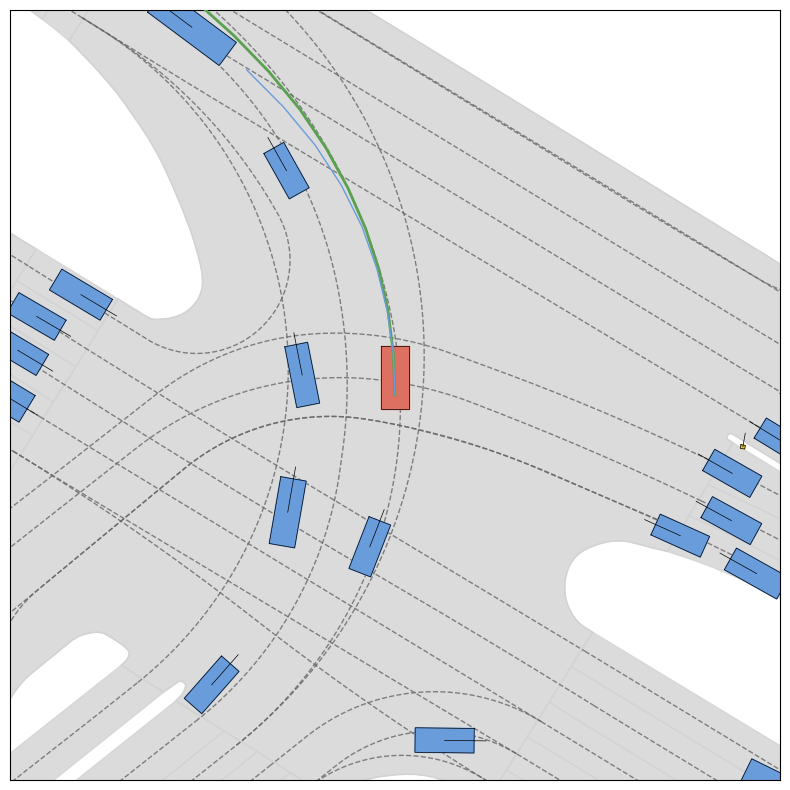

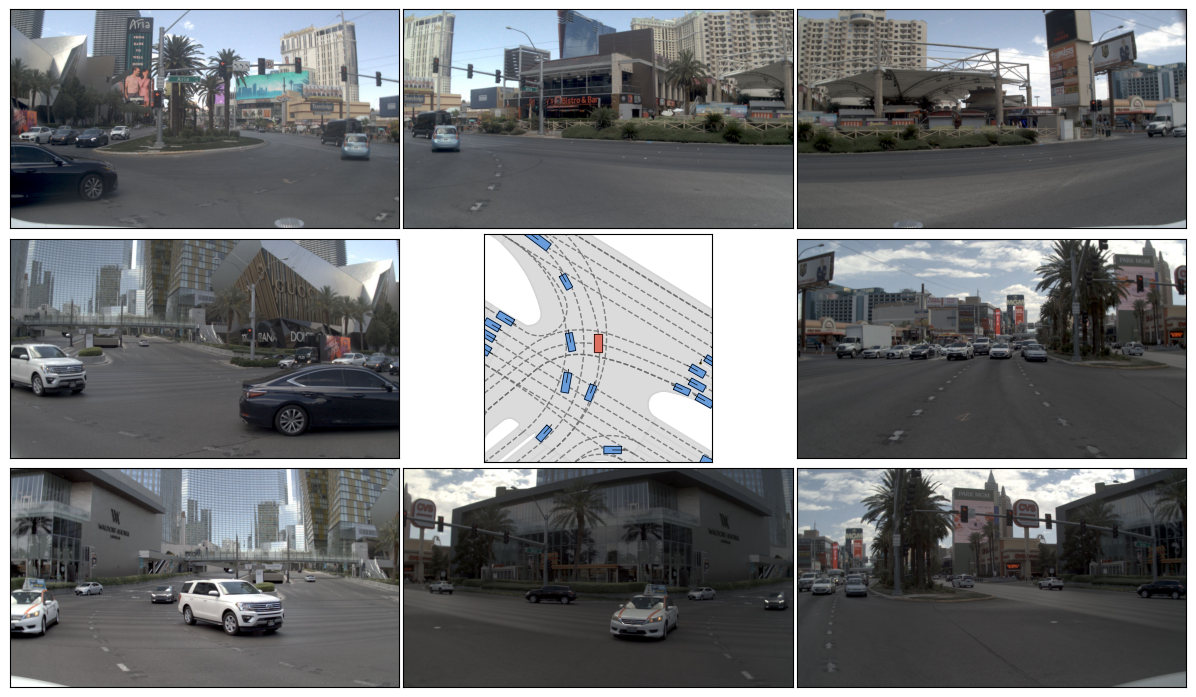

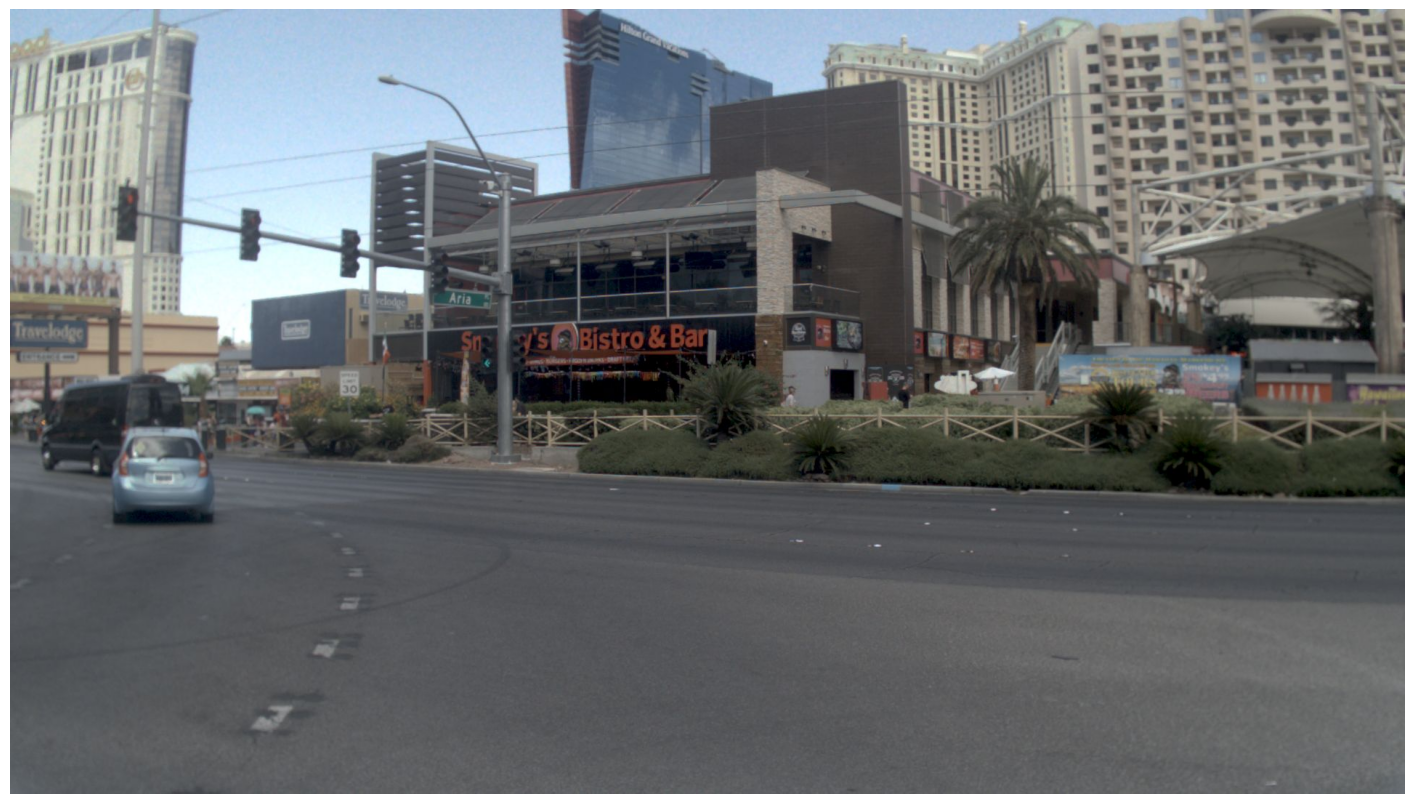

In [35]:
from navsim.visualization.plots import plot_bev_with_agent
from navsim.agents.transfuser.transfuser_agent import TransfuserAgent
from navsim.agents.transfuser.transfuser_config import TransfuserConfig
from navsim.visualization.plots import plot_cameras_frame
import matplotlib.pyplot as plt

# token = np.random.choice(scene_loader.tokens)
token ="358d973661955d68"
scene = scene_loader.get_scene_from_token(token)
frame_idx = scene.scene_metadata.num_history_frames - 1 # current frame


agent = TransfuserAgent(TransfuserConfig(), 1.0, "/home/ubuntu/project_ws/navsim/navsim/agents/transfuser/transfuser_seed_0.ckpt")
agent.initialize()
fig, ax = plot_bev_with_agent(scene, agent)
fig, ax = plot_cameras_frame(scene,frame_idx)

img = scene_loader.get_agent_input_from_token(token).cameras[-1].cam_f0.image
scene_loader.get_agent_input_from_token(token).cameras
plt.figure(figsize = (18,18))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
tft = ["214abdb588465704", "cd72b9f6b03f5f41", "384def2e3f9657f6", "6b8daf3b57175e70", "7a7e8074ee5c5389", "6704953640e55b83", "b9182baaae3b5ab2", "e7cfffa4e8dd53a8", "458ab847ffa957e8", "97c09fe94495563a"]
challenging = ["a90de87b906d51e8", "3be53588a286557f", "ba86ae71bc105215", "d26771df718251d1", "3e11d77a9aca5bb7", "25cdf7dee0d25a66", "97c09fe94495563a", "a41a728fda515594", "69f50b1f6c4d5f4b", "a4a08c828e87562c", "b762ea96cfa75157", "384def2e3f9657f6", "4024c1a4953e57a7", "b435be7b7b1b5dd4", "277cdfc9479e52c4", "ff1a4e51e3f558ce", "75151361dbe658bb"]
random = ["83c7a6c3c0b15b36",  "43066c8c8e325fcf",  "6b0ff02cbbf25aa3",  "2959d5dbe8235765",  "b4aeb4bbd9035964",  "c2a93dd3494b5702",  "6b8daf3b57175e70",  "26e7a31dd615509c",  "6922b2ea23cd51a3",  "ab313e9e217c581b",  "458ab847ffa957e8",  "4566a3d9b5e95d9b",  "96f6cde1205e5865",  "016d6a913efa5ff1",  "e194cef299cf5264",  "b02be1e28abb59f1",  "7f62e2a838405444",  "b619e01b47775ec5",  "bc2fe3314b345c63",  "92bbb17b853a5aa2",  "36077daf1cda5d05",  "6fcec1c4552351ed",  "6704953640e55b83",  "d4ac0a1865ac5c25",  "eb5989e21dc35a47",  "b9182baaae3b5ab2",  "9b7108902e7158d6",  "b9633d9afd4356a8",  "e7cfffa4e8dd53a8",  "76b3e192b5e45727",  "e0e228212a655d7f"]

The function `plot_bev_frame` takes a `Scene` and index of the step to visualize (history or future). 

In [ ]:
from navsim.visualization.plots import plot_bev_frame

fig, ax = plot_bev_frame(scene, frame_idx)
plt.show()

In [ ]:
from navsim.agents.deepseek.gpt_agent import GPTAgent
from navsim.agents.deepseek.gpt_config import GPTConfig
from navsim.visualization.plots import plot_bev_with_agent

agent = GPTAgent(GPTConfig)
agent.initialize()

fig, ax = plot_bev_with_agent(scene, agent)
plt.show()

## Loop

In [ ]:
from navsim.visualization.plots import plot_bev_with_agent, plot_bev_with_agent_with_traj
from navsim.agents.constant_velocity_agent import ConstantVelocityAgent
from navsim.agents.transfuser.transfuser_agent import TransfuserAgent
from navsim.agents.transfuser.transfuser_config import TransfuserConfig
from navsim.visualization.plots import plot_cameras_frame


# agent = ConstantVelocityAgent()
agent = TransfuserAgent(TransfuserConfig(), 1.0, "/home/ubuntu/project_ws/navsim/navsim/agents/transfuser/transfuser_seed_0.ckpt")
agent.initialize()
for token in challenging:
    scene = scene_loader.get_scene_from_token(token)
    fig, ax = plot_bev_with_agent(scene, agent)
    fig, ax = plot_cameras_frame(scene,frame_idx)
    
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt
img = scene_loader.get_agent_input_from_token(token).cameras[-1].cam_f0.image
scene_loader.get_agent_input_from_token(token).cameras
plt.figure(figsize = (18,18))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from navsim.visualization.plots import plot_cameras_frame

for token in tft:
    scene = scene_loader.get_scene_from_token(token)
    frame_idx = scene.scene_metadata.num_history_frames - 1
    fig, ax = plot_cameras_frame(scene, frame_idx)
plt.show()

In [ ]:
from navsim.visualization.plots import plot_cameras_frame_with_annotations

fig, ax = plot_cameras_frame_with_annotations(scene, frame_idx)
plt.show()

In [ ]:
from navsim.visualization.plots import plot_cameras_frame_with_lidar

fig, ax = plot_cameras_frame_with_lidar(scene, frame_idx)
plt.show()